In [1]:
import netCDF4 as nc
import numpy as np
import xarray as xr
import warnings
from eofs.xarray import Eof
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import gridspec
import datetime
import seaborn as sns
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from scipy.stats import linregress
from proj_utils import *
from mapping_utils import *
import matplotlib.patches as patch
import scipy.io as sio
import matplotlib.colors as mcolors

### Regression Functions

In [2]:
def linregress_at_point(var_one, var_two):
    if np.all(np.isnan(var_two)):  # Handle missing data
        return np.nan, np.nan, np.nan, np.nan, np.nan
    slope, intercept, r_value, p_value, std_err = linregress(var_one, var_two)
    return slope, intercept, r_value**2, p_value, std_err

In [3]:
def linregress_spatial(var_one, var_two):
    results = xr.apply_ufunc(
        linregress_at_point,
        var_one,    # (time,)
        var_two,    # (time, lat, lon)
        input_core_dims  = [['time'], ['time']],  # Apply along time axis
        output_core_dims = [[], [], [], [], []],  # Scalar outputs per point
        vectorize = True,  # Apply function element-wise
        dask = 'parallelized',  # Enables parallel computation if using Dask
        output_dtypes = [np.float64, np.float64, np.float64, np.float64, np.float64]
    )
    
    slope, intercept, r_squared, p_value, std_err = results
    slope     = xr.DataArray(slope,     dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    intercept = xr.DataArray(intercept, dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    r_squared = xr.DataArray(r_squared, dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    p_value   = xr.DataArray(p_value,   dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    std_err   = xr.DataArray(std_err,   dims=('latitude', 'longitude'), coords={'latitude': var_two.latitude, 'longitude': var_two.longitude})
    
    regression_results = xr.Dataset(
        {
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_squared,
            'p_value': p_value,
            'std_err': std_err,
        }
    )
    return regression_results

### File Loads, Preprocessing

In [4]:
data_path = '/Users/lillienders/Documents/gs_var/data/'
fig_path  = '/Users/lillienders/Documents/gs_var/figures/'

In [5]:
alt     = pd.read_csv(data_path + 'gsi/alt_gsi_locs.csv')

In [6]:
wsc_ds = xr.open_dataset(data_path + 'climate_fields/wsc.nc')
wsc_ds['longitude'] = wsc_ds.longitude + 360

In [7]:
wsc_ds = rmv_clm(wsc_ds)
wsc_ds = seasonal_detrend(wsc_ds)

In [8]:
slp_da = xr.open_dataset(data_path + 'era_downloads/north_atlantic_slp.nc')
slp_da = slp_da.sel(expver = slice(0,1))
slp_da = slp_da.squeeze()
slp_da = slp_da.drop_vars('expver')
slp_da = slp_da.sel(time = slice('1993-01-01','2023-12-01'))
slp_da = slp_da.sortby(slp_da.latitude)

In [9]:
slp_da = rmv_clm(slp_da)
slp_da = seasonal_detrend(slp_da)
slp_da['msl'] = slp_da['msl']/100 #Convert to Pa

In [10]:
eofs_full, pcs_full, per_var_full, eigs_full = calc_eofs(slp_da['msl'], num_modes=4)

/Users/lillienders/Documents/gs_var/proj_utils.py:319: RuntimeWarning: invalid value encountered in sqrt
  wgts = np.sqrt(coslat)[..., np.newaxis]


In [11]:
pcs_unscaled = pcs_full*np.sqrt(eigs_full[:4])

In [12]:
nao_ = -pcs_unscaled[:,0]

In [13]:
# --- Open Bathy --- 
f_name     = 'bathy/gebco_north_atlantic.nc'
bathy_ds   = xr.open_dataset(data_path + f_name)
bathy_ds   = bathy_ds.coarsen(lat=50, lon = 50).mean()
bathy_ds['lon'] = bathy_ds.lon + 360

### Regression NAO onto WSC (Full Period)

In [14]:
reg_nao_wsc = linregress_spatial(nao_, wsc_ds['wsc'])

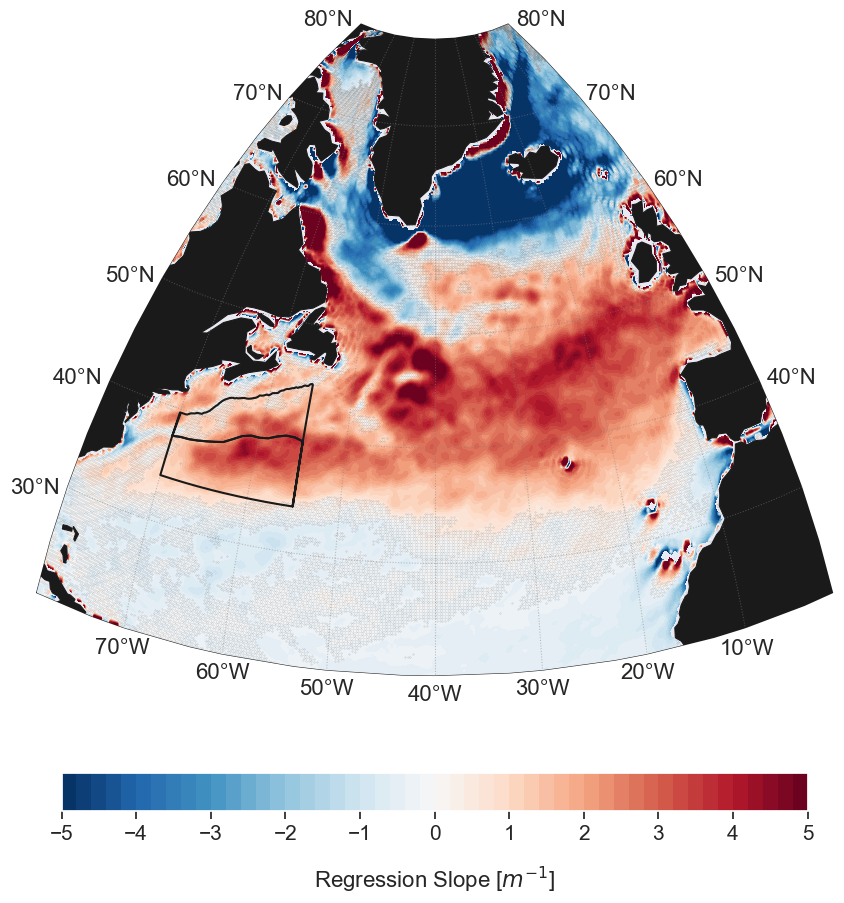

In [71]:
reg_nao_wsc.slope.data[reg_nao_wsc.slope.data > 5] = 5
reg_nao_wsc.slope.data[reg_nao_wsc.slope.data < -5] = -5

bbox          = [-80,0,20,80] # Plotting Extent
plot_this_box = [-80,0,0,60]    # Locator box indicating a region
proj          = ccrs.PlateCarree() # Need to add this to most things as "transform=proj"
fig,ax,_      = init_orthomap(1,1,bbox)
# Add Coasts/Continent
ax     = add_coast_grid(ax,bbox,fill_color='k',line_color='k')
levels = np.linspace(-5,5,51)
# Plot contours
colorplot = ax.contourf(reg_nao_wsc.longitude,reg_nao_wsc.latitude,reg_nao_wsc.slope,transform=proj, levels=levels, cmap='RdBu_r', zorder=0)
cbar = plt.colorbar(colorplot, fraction=0.057, pad=0.1, orientation='horizontal',ticks=np.linspace(-5, 5, 11))
cbar.set_label('Regression Slope [$m^{-1}$]', size='16', labelpad=15)
cbar.ax.tick_params(labelsize=15)
xorg = reg_nao_wsc.longitude.data
yorg = reg_nao_wsc.latitude.data
nlon = len(xorg)
nlat = len(yorg)
xdata = np.reshape(np.tile(xorg, nlat), reg_nao_wsc.slope.shape)
ydata = np.reshape(np.repeat(yorg, nlon), reg_nao_wsc.slope.shape)
xpoints = xdata[reg_nao_wsc.p_value > 0.05]
ypoints = ydata[reg_nao_wsc.p_value > 0.05]
ax.scatter(xpoints, ypoints, s=0.2, c='k', marker='.', alpha=0.3,transform=proj)

plt.plot(S_box_lon, S_box_lat,color = 'k',transform=proj)
plt.plot(N_box_lon, N_box_lat,color = 'k',transform=proj)

In [72]:
# --- Northern Box --- 
# Bound by 1000 m isobath to the north, GS mean path to the south, 70W and 55W 
# --- Define upper boundary of gyre (1000 m isobath) 
bathy_temp = bathy_ds.sel(lat = slice(35,45), lon = slice(290,305))
bathy_contours = plt.contour(bathy_temp.lon,bathy_temp.lat,abs(bathy_temp.elevation), levels = [2000], colors = 'k')
plt.close()
for collection in bathy_contours.collections:
    for path in collection.get_paths():
        vertices = path.vertices  # Extract contour points (lon, lat)
N_bathy_lon, N_bathy_lat = vertices[:,0], vertices[:,1]

gsi_lon, gsi_lat = alt['longitude'], alt['latitude']

N_west_bound_lat = np.arange(37.56,39.69,0.125)
N_west_bound_lon = np.tile(290,len(N_west_bound_lat)) 

N_east_bound_lat = np.arange(39.71,44.78,0.125)
N_east_bound_lon = np.tile(305,len(N_east_bound_lat)) 

/var/folders/cc/tkrb8rhn2rdcxs18lry79q580000gn/T/ipykernel_77833/3716106207.py:7: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for collection in bathy_contours.collections:


In [73]:
# --- Southern Box --- 
S_west_bound_lat = np.arange(34,37.65,0.125)
S_west_bound_lon = np.tile(290,len(S_west_bound_lat)) 

S_east_bound_lat = np.arange(34,39.71,0.125)
S_east_bound_lon = np.tile(305,len(S_east_bound_lat)) 

S_south_bound_lon = np.arange(290,305.25,0.25)
S_south_bound_lat = np.tile(34,len(S_south_bound_lon)) 


In [74]:
N_box_lon = np.hstack((gsi_lon,N_east_bound_lon,N_bathy_lon,N_west_bound_lon))
N_box_lat = np.hstack((gsi_lat,N_east_bound_lat,N_bathy_lat,N_west_bound_lat))

S_box_lon = np.hstack((gsi_lon,S_east_bound_lon,S_south_bound_lon[::-1],S_west_bound_lon))
S_box_lat = np.hstack((gsi_lat,S_east_bound_lat,S_south_bound_lat[::-1],S_west_bound_lat))

In [75]:
from shapely.geometry import Point, Polygon

lon2d, lat2d = np.meshgrid(wsc_ds.longitude,wsc_ds.latitude)
flat_points  = np.column_stack((lon2d.ravel(), lat2d.ravel()))

N_points     = list(zip(N_box_lon, N_box_lat))
N_poly       = Polygon(N_points)
N_mask       = np.array([N_poly.contains(Point(lon, lat)) for lon, lat in flat_points])
N_mask       = N_mask.reshape(lat2d.shape)
N_mask_3d    = xr.DataArray(N_mask, dims=('latitude', 'longitude')).broadcast_like(wsc_ds)

S_points     = list(zip(S_box_lon, S_box_lat))
S_poly       = Polygon(S_points)
S_mask       = np.array([S_poly.contains(Point(lon, lat)) for lon, lat in flat_points])
S_mask       = S_mask.reshape(lat2d.shape)
S_mask_3d    = xr.DataArray(S_mask, dims=('latitude', 'longitude')).broadcast_like(wsc_ds)

In [76]:
N_masked     = wsc_ds.where(N_mask_3d)
S_masked     = wsc_ds.where(S_mask_3d)
wsc_grad     = N_masked.wsc.mean() - S_masked.wsc.mean()

In [77]:
# For Each Window
wsc_grad = []
chunk_sz = 48 # months
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    for c in range(len(wsc_ds.time)-(chunk_sz)):
        print(c)
        nao_temp = nao_.sel(time = slice(nao_.time[c].data,nao_.time[c+chunk_sz].data))
        wsc_temp = wsc_ds.wsc.sel(time = slice(wsc_ds.time[c].data,wsc_ds.time[c+chunk_sz].data))

        reg_nao_wsc = linregress_spatial(nao_temp, wsc_temp)
        
        N_masked     = reg_nao_wsc.where(N_mask_3d)
        S_masked     = reg_nao_wsc.where(S_mask_3d)
        mask_temp    = N_masked.mean() - S_masked.mean()
        wsc_grad.append(mask_temp.slope)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [78]:
wsc_array = []

In [79]:
for t in range(len(wsc_grad)):
    wsc_array.append(wsc_grad[t].data)

In [80]:
wsc_array = np.squeeze(wsc_array)

In [81]:
wsc_array_norm = (wsc_array - np.nanmean(wsc_array))/np.nanstd(wsc_array)

In [82]:
f_path = '/Users/lillienders/Documents/gs_var/data/'


In [83]:
wsc_grad = xr.DataArray(
    data  = wsc_array_norm,
    dims  = ['time'],
    name  = 'wsc_grad',
    coords = dict(
        time = time_cent.data
    ),
    attrs=dict(
        description = 'Gradient of WSC/NAO regression slope across GS',
        units = '',
    ),
)
wsc_grad.to_netcdf(f_path + 'wsc_grad.nc')

NameError: name 'time_cent' is not defined

In [84]:
wsc_grad_f  = lanczos_bandpass(wsc_grad, low_freq = 12*6, high_freq = 12*11, window = 12) 
wsc_grad_f  = (wsc_grad_f - wsc_grad_f.mean(dim='time'))/wsc_grad_f.std(dim = 'time')

AttributeError: 'list' object has no attribute 'rolling'

NameError: name 'wsc_grad_f' is not defined

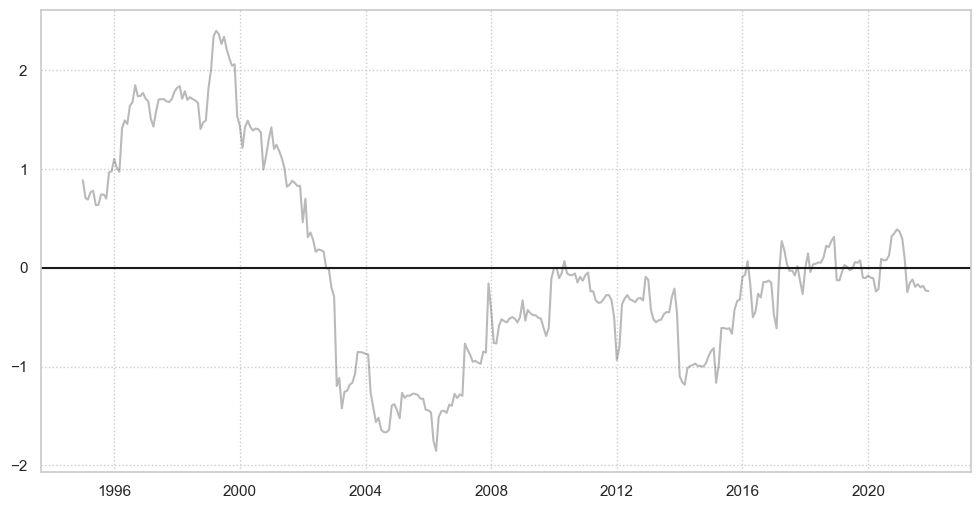

In [85]:
time_cent = wsc_ds.time[24:-24]
sns.set_style('whitegrid',{"grid.linestyle": ":"})
fig     = plt.figure(figsize=(12, 6))

zline = plt.axhline(0,color='k')
wsc_unfilt  = plt.plot(time_cent,wsc_array_norm, c = 'k', alpha = 0.3, label = 'Unfiltered')
wsc_filt    = plt.plot(time_cent,wsc_grad_f, c = 'k',label = 'Filtered')
#eap_unfilt  = plt.plot(time_cent,wsc_array_norm, c = '#648fff')

xtix = plt.yticks(fontsize=18)
xtix = plt.xticks(fontsize=18)

plt.ylim(-2.5,2.5)
plt.xlim(wsc_ds.time[0],wsc_ds.time[-1])
plt.legend(fontsize = 18)


In [ ]:
sns.set_style('whitegrid',{"grid.linestyle": ":"})
fig     = plt.figure(figsize=(14, 5))

plt.scatter(wsc_ds.time[24:-24],(wsc_grad), 50, c= '#fa4d56', edgecolors = 'k')

xtix = plt.yticks(fontsize=18)
xtix = plt.xticks(fontsize=18)

#ylab = plt.ylabel('Longitude of AH (˚W)',fontsize = 15)


